Project Scenario: Smart Waste Classification System
A city municipality wants to build an AI-powered waste segregation system that can automatically classify images of waste into:

Recyclable Waste

Organic Waste

Non-Recyclable Waste

You are required to build a deep learning image classifier that can perform this task.

Task 1 – Dataset Collection (5 Marks)
Download or collect a dataset of waste images from sources

https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification?utm_source=chatgpt.com


Organize the dataset into the following folder structure:

dataset/

   train/

       recyclable/

       organic/

       non_recyclable/


   validation/

       recyclable/

       organic/

       non_recyclable/


Deliverable:
• Show the dataset structure and total number of images in each class.

Task 2 – Data Preprocessing (5 Marks)
Perform the following preprocessing steps:

Resize images to a fixed size (e.g., 224×224)

Normalize pixel values

Apply data augmentation (at least 3 techniques)

Examples:

Rotation

Horizontal flip

Zoom

Brightness adjustment

Deliverable:
• Show the preprocessing pipeline code.

Task 3 – CNN Model Development (8 Marks)
Build an image classification model using CNN.

Your model should include:

Convolution layers

Pooling layers

Dense layers

Softmax output layer

Train the model and display:

Training accuracy

Validation accuracy

Training loss curve

Deliverable:

• Model architecture
• Training output
• Accuracy graph

Task 4 – Model Evaluation (6 Marks)
Evaluate the trained model using:

Confusion Matrix

Accuracy score

Sample predictions on test images

Deliverable:

• Confusion matrix visualization
• 5 test image predictions with predicted labels

Task 5 – Transfer Learning Implementation (6 Marks)
Improve your system by implementing Transfer Learning using a pretrained model such as:

ResNet50

MobileNetV2

VGG16

Steps:

Load a pretrained model

Freeze base layers

Add custom classification layers

Train the model

Compare results with your original CNN model.

Deliverable:

• Accuracy comparison between Custom CNN vs Transfer Learning model


TRAIN:
------------------------------
  recyclable  : 1436 images ✅
  organic     :  475 images ✅
  non_recyclable:  109 images ✅
  Total       : 2020 images

VALIDATION:
------------------------------
  recyclable  :  360 images ✅
  organic     :  119 images ✅
  non_recyclable:   28 images ✅
  Total       :  507 images


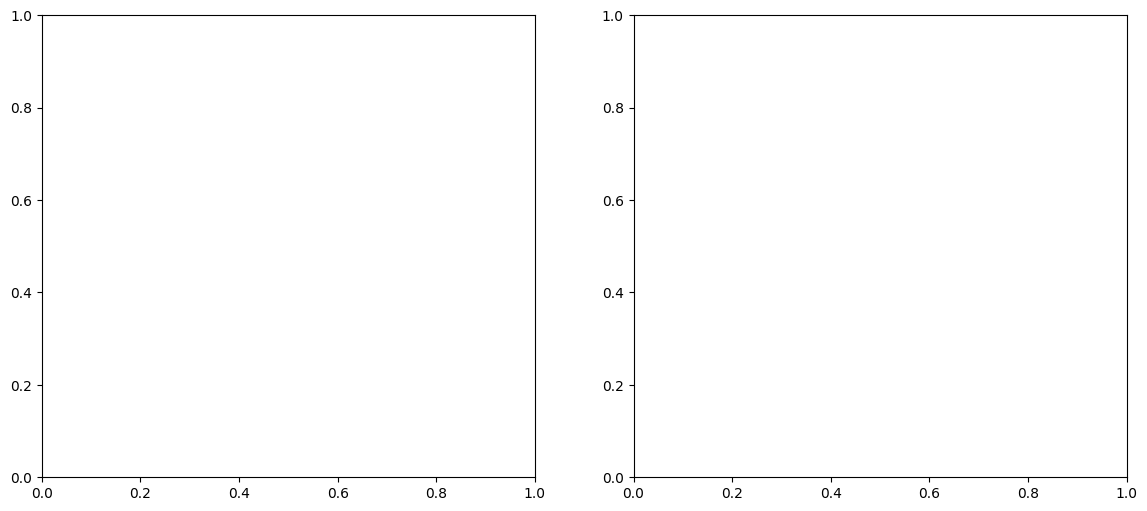


TRAIN:
------------------------------
  recyclable  : 1436 images ✅
  organic     :  475 images ✅
  non_recyclable:  109 images ✅
  Total       : 2020 images

VALIDATION:
------------------------------
  recyclable  :  360 images ✅
  organic     :  119 images ✅
  non_recyclable:   28 images ✅
  Total       :  507 images


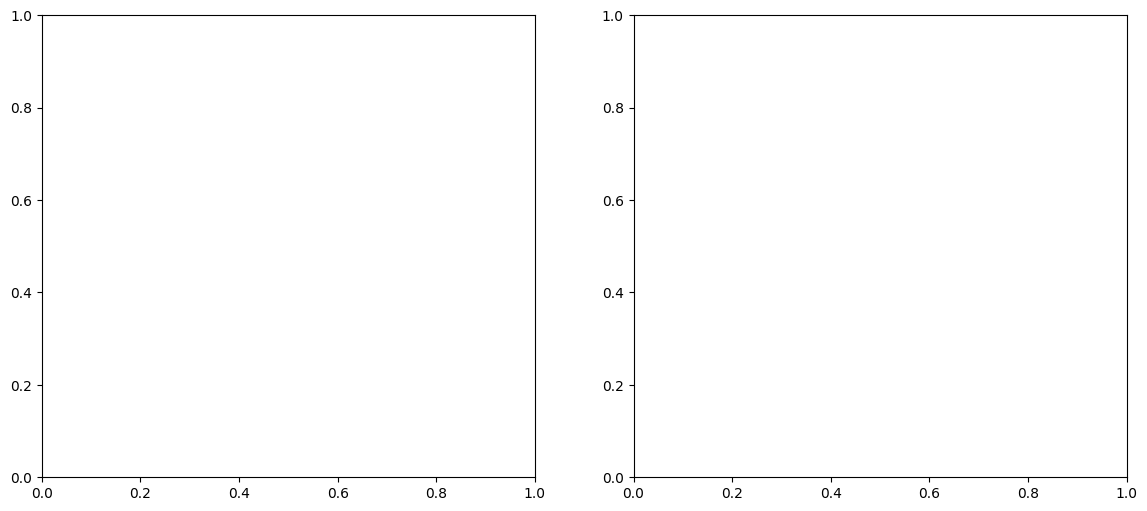

In [6]:
import tensorflow as tf
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = Path("dataset")
splits = ['train', 'validation']
categories = ['recyclable', 'organic', 'non_recyclable']

# Count images in each folder
for split in splits:
    print(f"\n{split.upper()}:")
    print("-" * 30)
    split_path = base_dir / split
    split_total = 0

    for category in categories:
        category_path = split_path / category
        # Count image files
        count = len(list(category_path.glob('*.jpg'))) + \
                len(list(category_path.glob('*.png'))) + \
                len(list(category_path.glob('*.jpeg')))

        status = "✅" if count > 0 else "❌ (empty)"
        print(f"  {category:12}: {count:4d} images {status}")
        split_total += count

    print(f"  {'Total':12}: {split_total:4d} images")

# VISUALIZATION (Professional deliverable)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# 1. Bar chart - Train vs Validation
categories = ['Recyclable', 'Organic', 'Non-Recyclable']
train_counts = []
val_counts = []

for category in ['recyclable', 'organic', 'non_recyclable']:
    train_path = base_dir / 'train' / category
    val_path = base_dir / 'validation' / category

    train_count = len(list(train_path.glob('*.jpg'))) + len(list(train_path.glob('*.png')))
    val_count = len(list(val_path.glob('*.jpg'))) + len(list(val_path.glob('*.png')))

    train_counts.append(train_count)
    val_counts.append(val_count)

In [7]:
train_data = ImageDataGenerator(
    rescale=1./255,   # normalize multiply every pixel by 1/255
    # DATA AUGMENTATION
    zoom_range=0.2,
    brightness_range=[0.8,1.2], # 80 to 120 percent bonus
    rotation_range =20
)

val_data = ImageDataGenerator(
    rescale=1./255,
)

train_generator = train_data.flow_from_directory(
    'dataset/train/',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)
val_generator = val_data.flow_from_directory(
    'dataset/validation/',
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
print(f"Train: {train_generator.samples} images, {len(train_generator.class_indices)} classes")
print(f"Validation: {val_generator.samples} images")
print(f"Classes: {train_generator.class_indices}")
print(f"Image shape: {train_generator.image_shape}")


Found 2020 images belonging to 3 classes.
Found 507 images belonging to 3 classes.
Train: 2020 images, 3 classes
Validation: 507 images
Classes: {'non_recyclable': 0, 'organic': 1, 'recyclable': 2}
Image shape: (224, 224, 3)
Found 2020 images belonging to 3 classes.
Found 507 images belonging to 3 classes.
Train: 2020 images, 3 classes
Validation: 507 images
Classes: {'non_recyclable': 0, 'organic': 1, 'recyclable': 2}
Image shape: (224, 224, 3)


C:\Users\singh\Desktop\DataScience_Training\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,561,891 (21.22 MB)

 Trainable params: 5,561,891 (21.22 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 463ms/step - accuracy: 0.6965 - loss: 0.8131 - val_accuracy: 0.7258 - val_loss: 0.7249
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 501ms/step - accuracy: 0.7297 - loss: 0.6655 - val_accuracy: 0.7318 - val_loss: 0.7034
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 40s 630ms/step - accuracy: 0.7520 - loss: 0.5682 - val_accuracy: 0.7101 - val_loss: 0.6489
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 37s 580ms/step - accuracy: 0.7936 - loss: 0.5001 - val_accuracy: 0.7692 - val_loss: 0.5732
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 600ms/step - accuracy: 0.7985 - loss: 0.4830 - val_accuracy: 0.7791 - val_loss: 0.5275


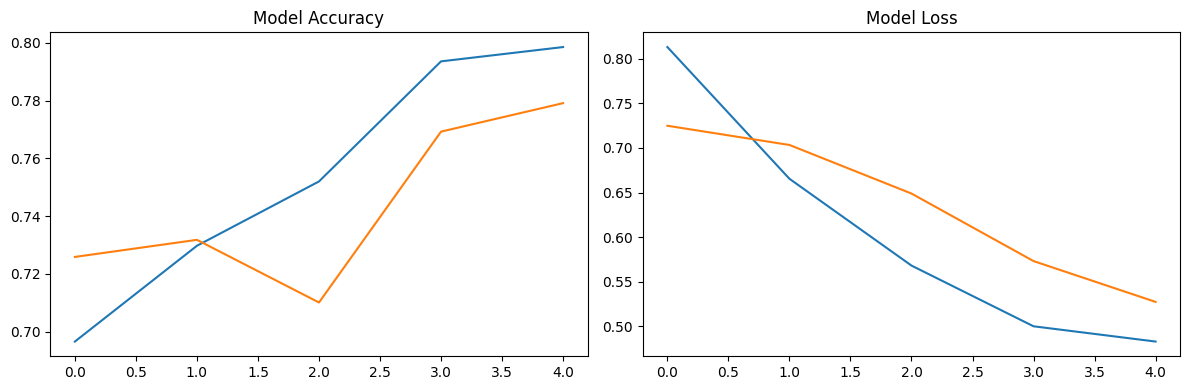

C:\Users\singh\Desktop\DataScience_Training\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,561,891 (21.22 MB)

 Trainable params: 5,561,891 (21.22 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 584ms/step - accuracy: 0.7089 - loss: 0.7970 - val_accuracy: 0.7416 - val_loss: 0.6544
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 478ms/step - accuracy: 0.7475 - loss: 0.6029 - val_accuracy: 0.7436 - val_loss: 0.5727
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 464ms/step - accuracy: 0.7693 - loss: 0.5374 - val_accuracy: 0.7653 - val_loss: 0.5320
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 472ms/step - accuracy: 0.7891 - loss: 0.5408 - val_accuracy: 0.7396 - val_loss: 0.6149
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 469ms/step - accuracy: 0.7728 - loss: 0.5293 - val_accuracy: 0.7712 - val_loss: 0.5465


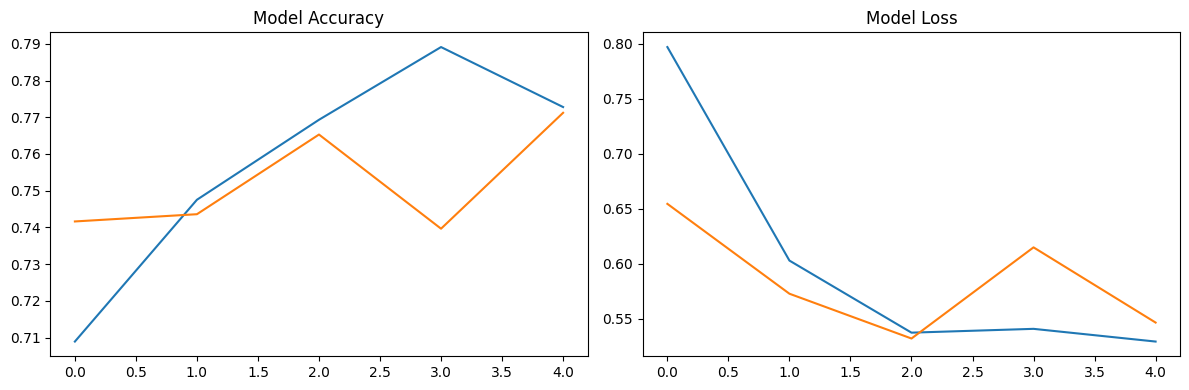

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(len(train_generator.class_indices), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    verbose=1
)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')

plt.tight_layout()
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step


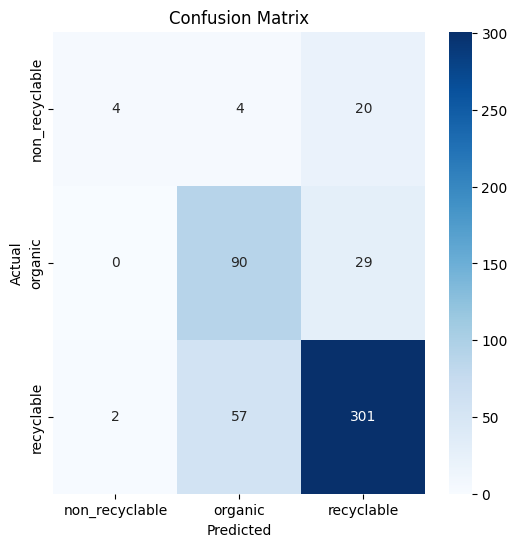

Accuracy: 0.7790927021696252
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


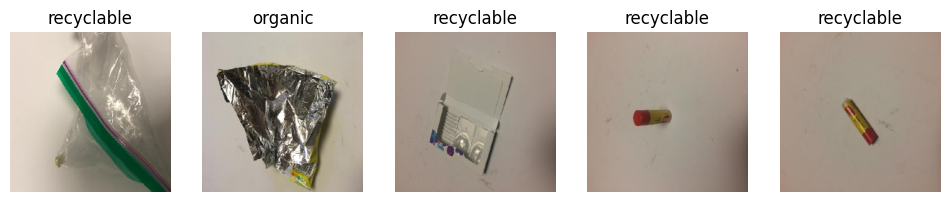

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step


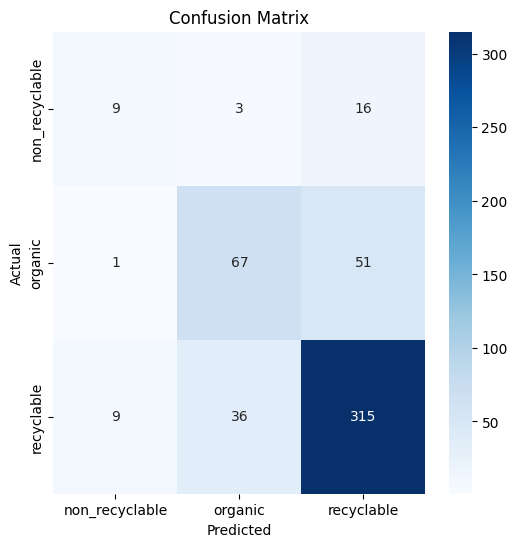

Accuracy: 0.7712031558185405
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


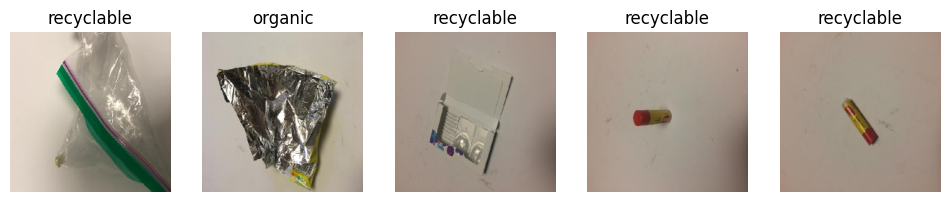

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

# Confusion Matrix
val_generator.reset()
pred = model.predict(val_generator)
y_pred = np.argmax(pred, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)
acc = accuracy_score(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Accuracy:", acc)


# 5 Test Image Predictions
class_names = list(val_generator.class_indices.keys())
images, labels = next(val_generator)

plt.figure(figsize=(12,6))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    prediction = model.predict(np.expand_dims(images[i], axis=0))
    predicted_label = class_names[np.argmax(prediction)]
    plt.title(predicted_label)
    plt.axis("off")

plt.show()

Epoch 1/2
64/64 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.7520 - loss: 0.6334 - val_accuracy: 0.8639 - val_loss: 0.3758
Epoch 2/2
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 859ms/step - accuracy: 0.8431 - loss: 0.3971 - val_accuracy: 0.9053 - val_loss: 0.2989


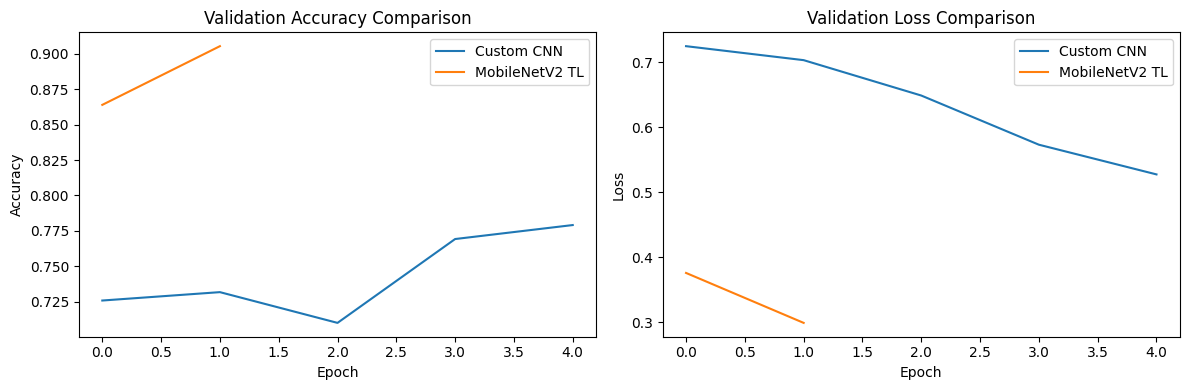

Custom CNN Final Val Acc: 0.779
MobileNetV2 Final Val Acc: 0.905
Epoch 1/2
64/64 ━━━━━━━━━━━━━━━━━━━━ 56s 806ms/step - accuracy: 0.7307 - loss: 0.6811 - val_accuracy: 0.8343 - val_loss: 0.3899
Epoch 2/2
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 823ms/step - accuracy: 0.8366 - loss: 0.4019 - val_accuracy: 0.8738 - val_loss: 0.3320


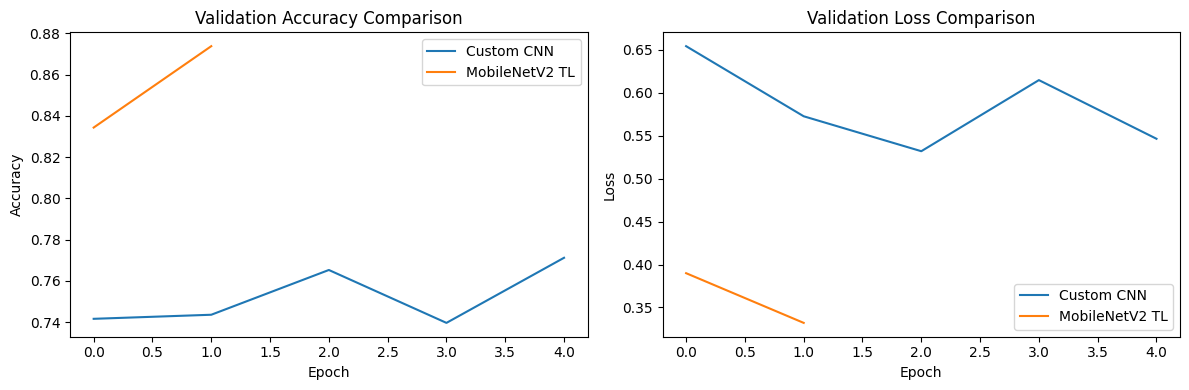

Custom CNN Final Val Acc: 0.771
MobileNetV2 Final Val Acc: 0.874


In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import numpy as np

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

tl_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.2),
    Dense(len(train_generator.class_indices), activation='softmax')
])

tl_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

tl_history = tl_model.fit(
    train_generator,
    epochs=2,
    validation_data=val_generator
)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['val_accuracy'], label='Custom CNN')
plt.plot(tl_history.history['val_accuracy'], label='MobileNetV2 TL')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['val_loss'], label='Custom CNN')
plt.plot(tl_history.history['val_loss'], label='MobileNetV2 TL')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('task5_comparison.png')
plt.show()

print(f"Custom CNN Final Val Acc: {max(history.history['val_accuracy']):.3f}")
print(f"MobileNetV2 Final Val Acc: {max(tl_history.history['val_accuracy']):.3f}")
